<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Breast_Cancer_Class_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.preprocessing import label_binarize

# Aesthetic config
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#2d3044',
    'grid.linewidth':   0.6,
    'axes.grid':        True,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

PALETTE = {'Benign': '#38bdf8', 'Malignant': '#f87171'}
C_BEN   = '#38bdf8'
C_MAL   = '#f87171'
C_ACC   = '#34d399'

print('All libraries imported successfully!')

All libraries imported successfully!


In [13]:
# Load dataset
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['diagnosis'] = cancer.target          # 0 = Malignant, 1 = Benign
df['diagnosis_label'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

print(f'Dataset shape  : {df.shape}')
print(f'Features       : {cancer.data.shape[1]}')
print(f'Target classes : {cancer.target_names.tolist()}')
print(f'\nClass distribution:')
print(df['diagnosis_label'].value_counts())

df.head(3)

Dataset shape  : (569, 32)
Features       : 30
Target classes : ['malignant', 'benign']

Class distribution:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant


In [14]:
# Train/test split
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 455
Test samples     : 114
Features         : 30


In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
# print("Accuracy:", accuracy)


#classification report

print("Logistic Regression")
print(classification_report(y_test, y_pred))

#

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



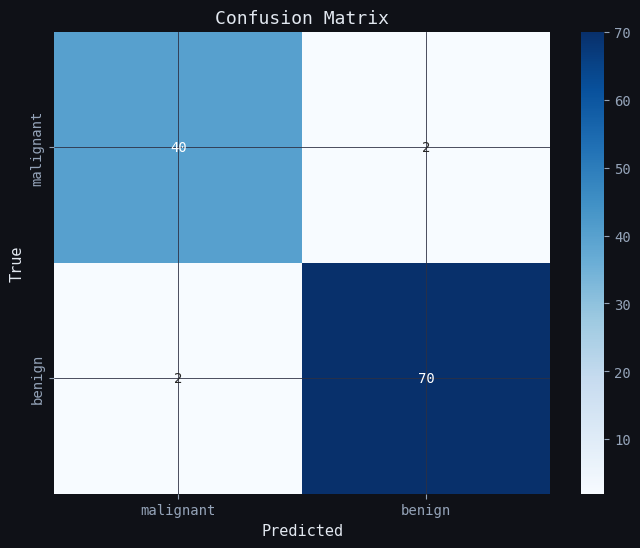

In [16]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


This code uses a Pipeline to strictly prevent data leakage during scaling and employs LogisticRegressionCV to automatically find the optimal regularization parameter ($C$) via stratified cross-validation. It also includes logic to invert the target variable so that "Malignant" is correctly treated as the positive class ($1$).

In [19]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# FIX 1: Initialize the dataset object
cancer = load_breast_cancer()

# FIX 2: Wrap X in a DataFrame so X.columns works in Step 5
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# FIX 3: Invert target so Malignant = 1. This aligns with scoring='recall'
# and the classification_report target_names mapping later.
y = 1 - cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}\n')

# 2. Define the Pipeline and CV Strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegressionCV(
        Cs=20,
        cv=cv_strategy,
        penalty='l1',
        solver='saga',
        scoring='recall',
        class_weight='balanced',
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])

# 3. Train the Model
pipeline.fit(X_train, y_train)

# 4. Evaluate Performance
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("--- Model Evaluation ---")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")

# 5. Extract Feature Importance (Sparsity check)
model = pipeline.named_steps['classifier']
feature_names = X.columns
coefficients = model.coef_[0]

# Filter out features that were zeroed out by the L1 penalty
active_features = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).loc[coefficients != 0].sort_values(by='Coefficient', ascending=False)

print("--- Active Features (Non-Zero Coefficients) ---")
print(active_features.to_string(index=False))
print(f"\nTotal features retained: {len(active_features)} out of {len(feature_names)}")
print(f"Optimal C value found: {model.C_[0]:.4f}")

Training samples : 455
Test samples     : 114
Features         : 30

--- Model Evaluation ---
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC-AUC Score: 0.9977

--- Active Features (Non-Zero Coefficients) ---
                Feature  Coefficient
           worst radius     2.970261
           radius error     2.155688
          worst texture     1.712582
    mean concave points     1.346206
        worst concavity     0.748847
   worst concave points     0.704546
         worst symmetry     0.499924
       worst smoothness     0.223127
       smoothness error     0.198702
             worst area     0.141177
   concave points error     0.039518
fractal dimension error    -0.292612
          texture error    

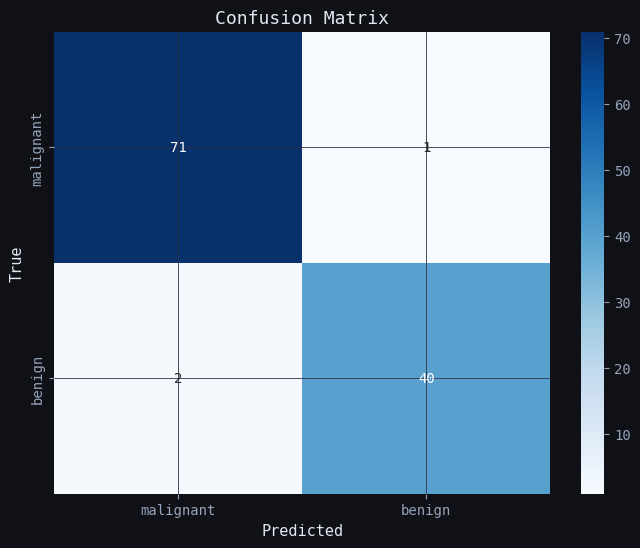

In [20]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
